### Low-power Efficient and Accurate Facial-Landmark Detection for Embedded Systems

#### Simple EDA
`2024-02-25`
https://aidea-web.tw/topic/b048c9a3-c3bc-4650-9674-f14f4c850f12?focus=intro
<img src="b048c9a3-c3bc-4650-9674-f14f4c850f12-big.png" width="500" height="150" class="center">

In [ ]:
!wget https://aidea-web.tw/images/65bc5b12936442deccb06369/b048c9a3-c3bc-4650-9674-f14f4c850f12-big.png

## import

In [1]:
import os
# import numpy as np


import matplotlib.pyplot as plt

## ivslab_facial_train.zip
```shell

$wget https://www.aicreda.com/download/iVSFacialDataset --no-check-certificate # it's a zip file.

$unzip iVSFacialDataset

$tree -d ivslab_facial_train/
ivslab_facial_train/
├── 300W
│   ├── images
│   └── labels
├── IFPW
│   ├── images
│   └── labels
├── afw
│   ├── images
│   └── labels
├── helen
│   ├── images
│   └── labels
└── ibug
    ├── images
    └── labels
    
$tree -a ivslab_facial_train/    
15 directories, 8874 files
```

In [2]:
data_root = '../data/ivslab_facial_train'
face_dirs = ['IFPW',
'afw',
'helen',
'300W',
'ibug']


In [3]:
os.listdir(f'{data_root}/{face_dirs[0]}')

['labels', 'images']

In [4]:
img_count = []
lab_count = []

faces_pts = []

for face in face_dirs:
    root = f'{data_root}/{face}/images'
    tmp_img_ls = [os.path.join(root, file) for file in sorted(os.listdir(root))]
    img_count.append(len(tmp_img_ls))

    root = f'{data_root}/{face}/labels'
    tmp_lab_ls = [os.path.join(root, file) for file in sorted(os.listdir(root))]
    lab_count.append(len(tmp_lab_ls))
    
    faces_pts.append(tmp_lab_ls)

In [5]:
len(tmp_img_ls)

135

In [6]:
tmp_img_ls[0]

'../data/ivslab_facial_train/ibug/images/image_003_1.jpg'

In [7]:
len(tmp_lab_ls)

135

In [8]:
tmp_lab_ls[0]

'../data/ivslab_facial_train/ibug/labels/image_003_1.pts'

In [12]:
print(face_dirs)

['IFPW', 'afw', 'helen', '300W', 'ibug']


In [9]:
img_count

[1035, 337, 2330, 600, 135]

In [10]:
lab_count

[1035, 337, 2330, 600, 135]

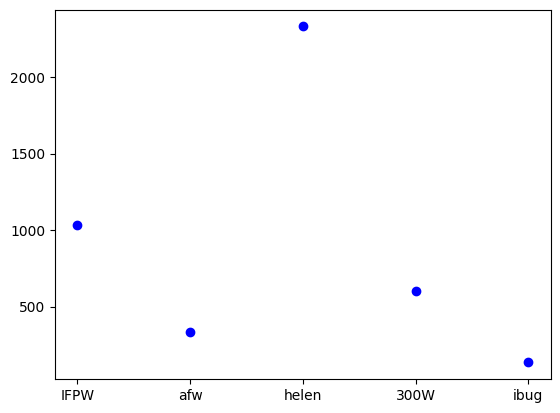

In [11]:
x=range(len(face_dirs))
plt.xticks(x, face_dirs)

plt.plot(x, img_count, 'bo')

plt.show()
# plt.plot(y1, 'g', y2, 'r')
# plt.show()

In [ ]:
len(faces_pts)

In [ ]:
len(faces_pts[-1])

In [ ]:
faces_pts[-1][0]

In [ ]:
with open('../data/ivslab_facial_train/ibug/labels/image_003_1.pts') as f:
    contents = f.read()
    print(contents)

```shell
ex. ibug
image_99
image_119
都超過一個人臉以上，但pts僅有一個人51點

image_100_01.jpg
image_100_02.jpg
image_100_03.jpg
image_100_04.jpg
image_100_05.jpg
image_100_06.jpg
image_100.jpg
是同一張影像，跟隨的pts座標點也不同，但畫面人數多於pts檔案數。


```

## 

In [ ]:
for top, dirs, files in os.walk(f'{data_root}'):
    
    print(f"TOP : {top}")
    
    print("Printing directories...")
    for dir in dirs:
        print(os.path.join(top, dir))
        
    print("Printing files....")
    for file in files:
        print(os.path.join(top, file))

### Ref to https://github.com/nikhilroxtomar/Human-Face-Landmark-Detection-in-TensorFlow

2024-03-11




In [17]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import sys

import numpy as np
import cv2
from glob import glob

import tensorflow as tf
from tensorflow.keras import layers as L
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger



import matplotlib.pyplot as plt


global image_h
global image_w
global num_landmarks




In [18]:
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [19]:
""" Seeding """
np.random.seed(42)
tf.random.set_seed(42)

""" Directory for storing files """
create_dir("files")

""" Hyperparameters """
image_h = 512
image_w = 512
num_landmarks = 51 #106
input_shape = (image_h, image_w, 3)
batch_size = 128 #64 #32
lr = 1e-3
num_epochs = 100

""" Paths """
#    dataset_path = "/media/nikhil/Seagate Backup Plus Drive/ML_DATASET/LaPa"
dataset_path = "../data/ivslab_facial_train/"
model_path = os.path.join("files", "0311-1220")
csv_path = os.path.join("files", "0311-1220", "data.csv")

In [20]:
def load_dataset(path):
    train_x = sorted(glob(os.path.join(path, "300W", "images", "*.png")))
    train_y = sorted(glob(os.path.join(path, "300W", "labels", "*.pts")))

    valid_x = sorted(glob(os.path.join(path, "afw", "images", "*.jpg")))
    valid_y = sorted(glob(os.path.join(path, "afw", "labels", "*.pts")))

    test_x = sorted(glob(os.path.join(path, "afw", "images", "*.jpg")))
    test_y = sorted(glob(os.path.join(path, "afw", "labels", "*.pts")))

    return (train_x, train_y), (valid_x, valid_y), (test_x, test_y)
    

def read_image_lankmarks(image_path, landmark_path):
    
    """ Check """
    #print(f'image_path: {image_path}')
    
    """ Image """
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    h, w, _ = image.shape
    image = cv2.resize(image, (image_w, image_h))
    image = image/255.0
    image = image.astype(np.float32)

    """ Lankmarks """
    #data = open(landmark_path, "r").read()
    data = open(landmark_path, "r").read()[26:-2]
    lankmarks = []
    
    #check
    #print(data)

    #for line in data.strip().split("\n")[1:]: ##the example txt has a dump ""
    for line in data.strip().split("\n"):
        x, y = line.split(" ")
        x = float(x)/w
        y = float(y)/h

        lankmarks.append(x)
        lankmarks.append(y)

    lankmarks = np.array(lankmarks, dtype=np.float32)

    return image, lankmarks


def preprocess(x, y):
    def f(x, y):
        x = x.decode()
        y = y.decode()

#         x = np.char.decode(x)
#         y = np.char.decode(y)
        
#         print(x)

        image, landmarks = read_image_lankmarks(x, y)
        return image, landmarks

    image, landmarks = tf.numpy_function(f, [x, y], [tf.float32, tf.float32])
    image.set_shape([image_h, image_w, 3])
    landmarks.set_shape([num_landmarks * 2])

    return image, landmarks

def tf_dataset(x, y, batch=8):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.shuffle(buffer_size=5000).map(preprocess)
    ds = ds.batch(batch).prefetch(256)
    return ds
    
def build_model(input_shape, num_landmarks):
    inputs = L.Input(input_shape)

    backbone = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs, alpha=0.5)
    backbone.trainable = True

    x = backbone.output
    x = L.GlobalAveragePooling2D()(x)
    x = L.Dropout(0.2)(x)
    outputs = L.Dense(num_landmarks*2, activation="sigmoid")(x)

    model = tf.keras.models.Model(inputs, outputs)
    return model

### if __name__ == "__main__":

In [21]:


""" Loading the dataset """
(train_x, train_y), (valid_x, valid_y), (test_x, test_y) = load_dataset(dataset_path)
print(f"Train: {len(train_x)}/{len(train_y)} - Valid: {len(valid_x)}/{len(valid_y)} - Test: {len(test_x)}/{len(test_x)}")
print("")



""" Dataset Pipeline """
print('Create TFdataset...')
train_ds = tf_dataset(train_x, train_y, batch=batch_size)
valid_ds = tf_dataset(valid_x, valid_y, batch=batch_size)

""" Model """
model = build_model(input_shape, num_landmarks)
# model.compile(loss="binary_crossentropy", optimizer=tf.keras.optimizers.Adam(lr))
model.compile(loss=tf.keras.losses.MeanSquaredError(), optimizer=tf.keras.optimizers.Adam(lr), metrics=[tf.keras.metrics.MeanSquaredError()])



# print(model.summary())



Train: 600/600 - Valid: 337/337 - Test: 337/337

Create TFdataset...


In [22]:
""" Training """
callbacks = [
    ModelCheckpoint(model_path, verbose=1, save_best_only=True, monitor='val_loss'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-7, verbose=1),
    CSVLogger(csv_path, append=True),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=False)
]

model.fit(train_ds,
    validation_data=valid_ds,
    epochs=num_epochs,
    callbacks=callbacks
)

Epoch 1/100
5/5 [==============================] - ETA: 0s - loss: 0.0414 - mean_squared_error: 0.0414
Epoch 1: val_loss improved from inf to 0.05443, saving model to files/0311-1220
INFO:tensorflow:Assets written to: files/0311-1220/assets


INFO:tensorflow:Assets written to: files/0311-1220/assets


5/5 [==============================] - 137s 13s/step - loss: 0.0414 - mean_squared_error: 0.0414 - val_loss: 0.0544 - val_mean_squared_error: 0.0544 - lr: 0.0010
Epoch 2/100
5/5 [==============================] - ETA: 0s - loss: 0.0275 - mean_squared_error: 0.0275 
Epoch 2: val_loss did not improve from 0.05443
5/5 [==============================] - 77s 16s/step - loss: 0.0275 - mean_squared_error: 0.0275 - val_loss: 0.0972 - val_mean_squared_error: 0.0972 - lr: 0.0010
Epoch 3/100
5/5 [==============================] - ETA: 0s - loss: 0.0244 - mean_squared_error: 0.0244 
Epoch 3: val_loss did not improve from 0.05443
5/5 [==============================] - 67s 13s/step - loss: 0.0244 - mean_squared_error: 0.0244 - val_loss: 0.1130 - val_mean_squared_error: 0.1130 - lr: 0.0010
Epoch 4/100


KeyboardInterrupt: 

##### erros

Node: 'IteratorGetNext'
2 root error(s) found.
  (0) INVALID_ARGUMENT:  Incompatible shapes at component 1: expected [?,102] but got [32,100].
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_3]]
  (1) INVALID_ARGUMENT:  Incompatible shapes at component 1: expected [?,102] but got [32,100].
	 [[{{node IteratorGetNext}}]]
     
     
某個地方少了一點座標 102--->100

#### check 

In [ ]:
print(train_x[0], '\n', train_y[0])

In [ ]:
t_x, t_y = preprocess(train_x[0], train_y[0])

In [ ]:
!ls ../data/ivslab_facial_train/300W/images/001.png

In [ ]:
t_x, t_y = read_image_lankmarks(train_x[2], train_y[2])

In [ ]:
def plot_lankmarks(image, landmarks):
    h, w, _ = image.shape
    radius = int(h * 0.005)

    for i in range(0, len(landmarks), 2):
        x = int(landmarks[i] * w)
        y = int(landmarks[i+1] * h)

        image = cv2.circle(image, (x, y), radius, (255, 0, 0), -1)

    return image

In [ ]:
len(t_y)

In [ ]:
gt_landmarks = plot_lankmarks(t_x.copy(), t_y)
cv2.imwrite(f"results/check_fd_001.png", gt_landmarks)

In [ ]:
plt.imshow(t_x.copy())

In [ ]:
plt.imshow(gt_landmarks)